<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Sales_(Udemy).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

import time
# Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")


⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 3.109 detik
Eksekusi berikutnya: 0.000 detik


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
data = pd.read_excel("SALES.xlsx")

In [6]:
print("Preview data:")
display(data.head())

Preview data:


,Date,Segment,Country,Product,Discount Band,Units Sold,Sale Price,Discounts,Sales,COGS,Profit
0,2014-12-01,Government,Germany,Carretera,NaN,1513.0,350,0.0,529550.0,393380,136170.0
1,2014-06-01,Government,Germany,Paseo,NaN,1006.0,350,0.0,352100.0,261560,90540.0
2,2013-11-01,Government,Canada,Paseo,NaN,1725.0,350,0.0,603750.0,448500,155250.0
3,2014-12-01,Government,Germany,Paseo,NaN,1513.0,350,0.0,529550.0,393380,136170.0
4,2014-06-01,Government,Germany,Velo,NaN,1006.0,350,0.0,352100.0,261560,90540.0


In [37]:
source_columns_to_process = ['Units Sold', 'Sale Price', ' Sales', 'COGS', 'Profit']

print("\nDataFrame bersih dan terformat:")
display(data.head())


DataFrame bersih dan terformat:


,Segment,Country,Product,Discount Band,Discounts,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD)
0,Government,Germany,Carretera,No Discounts,0.0,"$1,513.00",$350.00,"$529,550.00","$393,380.00","$136,170.00"
1,Government,Germany,Paseo,No Discounts,0.0,"$1,006.00",$350.00,"$352,100.00","$261,560.00","$90,540.00"
2,Government,Canada,Paseo,No Discounts,0.0,"$1,725.00",$350.00,"$603,750.00","$448,500.00","$155,250.00"
3,Government,Germany,Paseo,No Discounts,0.0,"$1,513.00",$350.00,"$529,550.00","$393,380.00","$136,170.00"
4,Government,Germany,Velo,No Discounts,0.0,"$1,006.00",$350.00,"$352,100.00","$261,560.00","$90,540.00"


In [7]:
print("\nInfo kolom:")
print(data.info())


Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           700 non-null    datetime64[ns]
 1   Segment        700 non-null    object        
 2   Country        700 non-null    object        
 3   Product        700 non-null    object        
 4   Discount Band  647 non-null    object        
 5   Units Sold     700 non-null    float64       
 6   Sale Price     700 non-null    int64         
 7   Discounts      700 non-null    float64       
 8    Sales         700 non-null    float64       
 9   COGS           700 non-null    int64         
 10  Profit         700 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(4)
memory usage: 60.3+ KB
None


In [12]:
print("\nChecking for missing values:")
print(data.isnull().sum())

# Mengisi nilai yang hilang di kolom 'Discount Band' dengan 'No Discounts'
data['Discount Band'] = data['Discount Band'].fillna('No Discounts')


Checking for missing values:
Date             0
Segment          0
Country          0
Product          0
Discount Band    0
Units Sold       0
Sale Price       0
Discounts        0
 Sales           0
COGS             0
Profit           0
dtype: int64


In [13]:
print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())


Checking for duplicate rows before dropping:
0

Checking for duplicate rows after dropping:
0


# Bussines Problem

Bagaimana kita dapat mengidentifikasi faktor-faktor kunci yang mempengaruhi profitabilitas penjualan di berbagai segmen produk dan negara, serta mengembangkan strategi untuk meningkatkan pendapatan dan margin keuntungan secara keseluruhan?

In [61]:
print("Re-identifying financial columns and converting them to numeric...")

financial_usd_columns = [col for col in data.columns if col.endswith('(USD)')]

for col_usd in financial_usd_columns:
    if col_usd in data.columns:
        data[col_usd] = data[col_usd].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
        data[col_usd] = pd.to_numeric(data[col_usd], errors='coerce')

print("Data types of financial (USD) columns after final conversion:")
print(data[financial_usd_columns].dtypes)

Re-identifying financial columns and converting them to numeric...
Data types of financial (USD) columns after final conversion:
Units Sold (USD)    float64
Sale Price (USD)    float64
Sales (USD)         float64
COGS (USD)          float64
Profit (USD)        float64
dtype: object


In [62]:
print("\nFirst 5 rows of the DataFrame with finally updated columns:")
display(data.head())


First 5 rows of the DataFrame with finally updated columns:


,Segment,Country,Product,Discount Band,Discounts,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD),Cluster
0,Government,Germany,Carretera,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951,1
1,Government,Germany,Paseo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084,1
2,Government,Canada,Paseo,No Discounts,-0.573087,0.134638,1.694287,1.835247,1.487458,3.068475,1
3,Government,Germany,Paseo,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951,1
4,Government,Germany,Velo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084,1


## Feature Scaling

Untuk melakukan *feature scaling*, kita perlu memastikan bahwa semua kolom numerik yang akan diskalakan berada dalam tipe data numerik. Kolom-kolom yang berakhiran `(USD)` saat ini berformat `object` (string) karena sudah diformat mata uang. Kita akan mengkonversikannya kembali ke `float64`.

Setelah itu, kita akan menggunakan `StandardScaler` dari scikit-learn untuk menormalisasi kolom-kolom numerik ini. `StandardScaler` bekerja dengan mengurangi rata-rata dan menskalakan ke variansi unit, yang menghasilkan distribusi dengan rata-rata 0 dan standar deviasi 1. Ini membantu model *machine learning* berkinerja lebih baik, terutama model yang menggunakan perhitungan jarak atau optimisasi berbasis gradien.

In [63]:
from sklearn.preprocessing import StandardScaler

print("Mengkonversi kolom (USD) kembali ke numerik...")

financial_usd_columns = [col for col in data.columns if col.endswith('(USD)')]

for col in financial_usd_columns:
    data[col] = data[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Tipe data kolom finansial setelah konversi:")
print(data[financial_usd_columns].dtypes)

Mengkonversi kolom (USD) kembali ke numerik...
Tipe data kolom finansial setelah konversi:
Units Sold (USD)    float64
Sale Price (USD)    float64
Sales (USD)         float64
COGS (USD)          float64
Profit (USD)        float64
dtype: object


In [64]:
print("\nMenerapkan Feature Scaling...")

columns_to_scale = financial_usd_columns + ['Discounts']

scaler = StandardScaler()

data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])

print("\nDataFrame setelah Feature Scaling (5 baris pertama):")
display(data.head())


Menerapkan Feature Scaling...

DataFrame setelah Feature Scaling (5 baris pertama):


,Segment,Country,Product,Discount Band,Discounts,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD),Cluster
0,Government,Germany,Carretera,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951,1
1,Government,Germany,Paseo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084,1
2,Government,Canada,Paseo,No Discounts,-0.573087,0.134638,1.694287,1.835247,1.487458,3.068475,1
3,Government,Germany,Paseo,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951,1
4,Government,Germany,Velo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084,1


In [65]:
print("\nStatistik deskriptif kolom yang diskalakan:")
display(data[columns_to_scale].describe())


Statistik deskriptif kolom yang diskalakan:


,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD),Discounts
count,7.000000e+02,7.000000e+02,7.000000e+02,7.000000e+02,7.000000e+02,7.000000e+02
mean,1.268826e-17,9.389315e-17,-2.283887e-17,-1.015061e-17,6.090366e-17,5.075305e-18
std,1.000715e+00,1.000715e+00,1.000715e+00,1.000715e+00,1.000715e+00,1.000715e+00
min,-1.624690e+00,-8.152647e-01,-7.099932e-01,-7.095883e-01,-1.515358e+00,-5.730871e-01
25%,-8.113610e-01,-7.786823e-01,-6.496571e-01,-6.773283e-01,-4.991309e-01,-5.382095e-01
50%,-7.590410e-02,-7.201505e-01,-5.667503e-01,-6.036192e-01,-3.485054e-01,-4.604229e-01
75%,7.162263e-01,1.328463e+00,3.866652e-01,4.915196e-01,-3.444554e-02,1.222839e-01
max,3.327387e+00,1.694287e+00,4.183305e+00,3.952241e+00,5.571396e+00,5.949797e+00


In [45]:
print("Tampilan DataFrame setelah Feature Scaling:")
display(data.head())

Tampilan DataFrame setelah Feature Scaling:


,Segment,Country,Product,Discount Band,Discounts,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD)
0,Government,Germany,Carretera,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951
1,Government,Germany,Paseo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084
2,Government,Canada,Paseo,No Discounts,-0.573087,0.134638,1.694287,1.835247,1.487458,3.068475
3,Government,Germany,Paseo,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951
4,Government,Germany,Velo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084


## Analisis Sales per Segmentasi

Hitung rata-rata atau total 'Sales (USD)' untuk setiap kategori di kolom 'Segment', 'Country', 'Product', dan 'Discount Band'.


In [41]:
print("Menghitung total 'Sales (USD)' per segmentasi...")

# 1. Hitung total 'Sales (USD)' untuk setiap kategori unik di kolom 'Segment'
sales_by_segment = data.groupby('Segment')['Sales (USD)'].sum().reset_index()
print("\nTotal Sales (USD) per Segment:")
display(sales_by_segment)

# 2. Hitung total 'Sales (USD)' untuk setiap kategori unik di kolom 'Country'
sales_by_country = data.groupby('Country')['Sales (USD)'].sum().reset_index()
print("\nTotal Sales (USD) per Country:")
display(sales_by_country)

# 3. Hitung total 'Sales (USD)' untuk setiap kategori unik di kolom 'Product'
sales_by_product = data.groupby('Product')['Sales (USD)'].sum().reset_index()
print("\nTotal Sales (USD) per Product:")
display(sales_by_product)

# 4. Hitung total 'Sales (USD)' untuk setiap kategori unik di kolom 'Discount Band'
sales_by_discount_band = data.groupby('Discount Band')['Sales (USD)'].sum().reset_index()
print("\nTotal Sales (USD) per Discount Band:")
display(sales_by_discount_band)

Menghitung total 'Sales (USD)' per segmentasi...

Total Sales (USD) per Segment:


,Segment,Sales (USD)
0,Channel Partners,1800593.64
1,Enterprise,19611694.38
2,Government,52504260.68
3,Midmarket,2381883.08
4,Small Business,42427918.50



Total Sales (USD) per Country:


,Country,Sales (USD)
0,Canada,24887654.89
1,France,24354172.29
2,Germany,23505340.82
3,Mexico,20949352.11
4,United States of America,25029830.17



Total Sales (USD) per Product:


,Product,Sales (USD)
0,Amarilla,17747116.06
1,Carretera,13815307.89
2,Montana,15390801.88
3,Paseo,33011143.96
4,VTT,20511921.02
5,Velo,18250059.47



Total Sales (USD) per Discount Band:


,Discount Band,Sales (USD)
0,High,37372486.73
1,Low,34629778.71
2,Medium,38780430.84
3,No Discounts,7943654.00


## Visualisasi Sales per Segmentasi

Menunjukkan bagaimana 'Sales (USD)' bervariasi di setiap 'Segment', 'Country', 'Product', dan 'Discount Band'. Sertakan legenda yang jelas untuk setiap visualisasi.


Membuat visualisasi total 'Sales (USD)' per segmentasi...


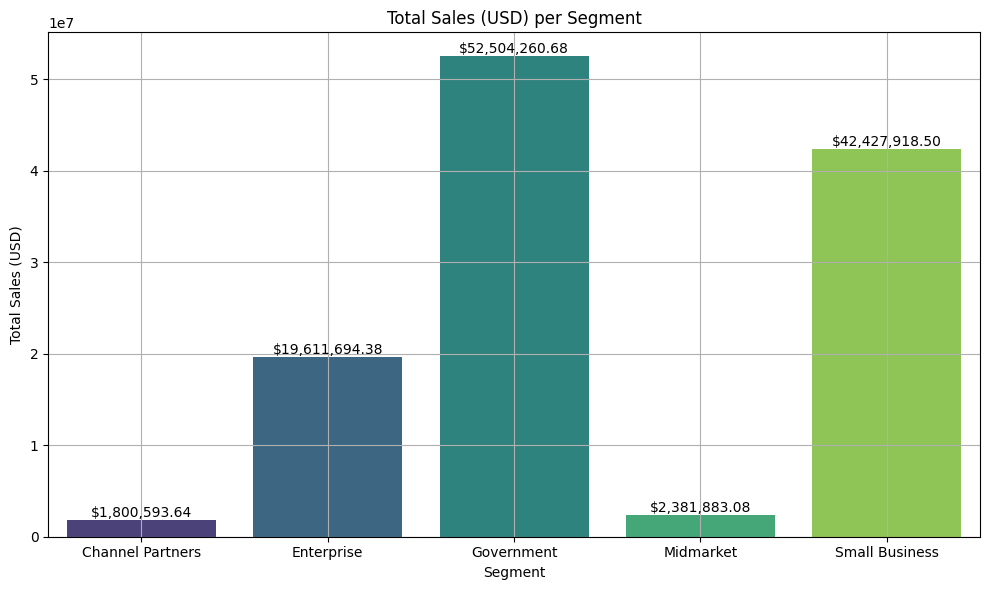

In [68]:
print("Membuat visualisasi total 'Sales (USD)' per segmentasi...")

# Bar chart untuk 'Sales (USD)' per Segment
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Segment', y='Sales (USD)', data=sales_by_segment, hue='Segment', palette='viridis', legend=False)
plt.title('Total Sales (USD) per Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales (USD)')
plt.grid(True)
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.2f}')
plt.tight_layout()
plt.show()

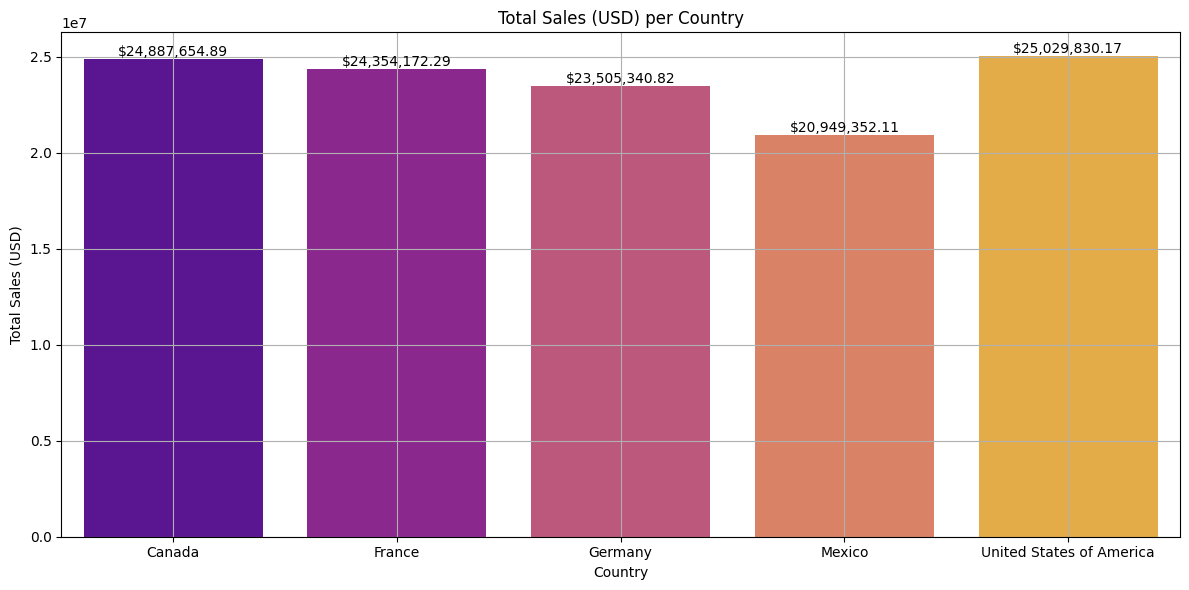

In [73]:
# Bar chart untuk 'Sales (USD)' per Country
plt.figure(figsize=(12, 6))
ax2 = sns.barplot(x='Country', y='Sales (USD)', data=sales_by_country, hue='Country', palette='plasma', legend=False)
plt.title('Total Sales (USD) per Country')
plt.xlabel('Country')
plt.ylabel('Total Sales (USD)')
plt.grid(True)
for container in ax2.containers:
    ax2.bar_label(container, fmt='${:,.2f}')
plt.tight_layout()
plt.show()

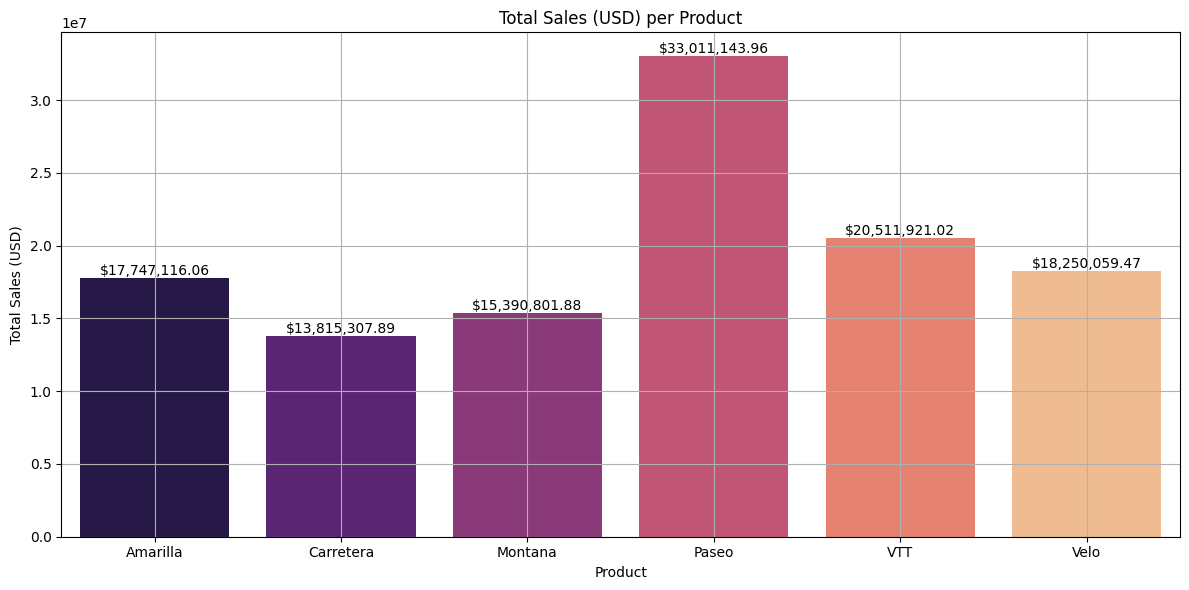

In [74]:
# Bar chart untuk 'Sales (USD)' per Product
plt.figure(figsize=(12, 6))
ax3 = sns.barplot(x='Product', y='Sales (USD)', data=sales_by_product, hue='Product', palette='magma', legend=False)
plt.title('Total Sales (USD) per Product')
plt.xlabel('Product')
plt.ylabel('Total Sales (USD)')
plt.grid(True)
for container in ax3.containers:
    ax3.bar_label(container, fmt='${:,.2f}')
plt.tight_layout()
plt.show()

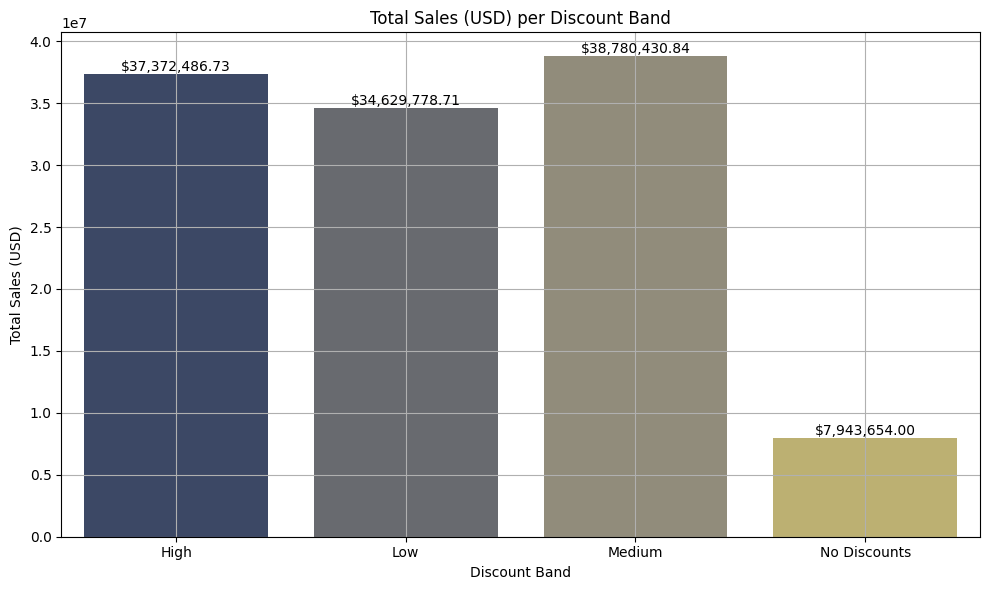

In [75]:
# Bar chart untuk 'Sales (USD)' per Discount Band
plt.figure(figsize=(10, 6))
ax4 = sns.barplot(x='Discount Band', y='Sales (USD)', data=sales_by_discount_band, hue='Discount Band', palette='cividis', legend=False)
plt.title('Total Sales (USD) per Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Total Sales (USD)')
plt.grid(True)
for container in ax4.containers:
    ax4.bar_label(container, fmt='${:,.2f}')
plt.tight_layout()
plt.show()

## Feature Selection

Berdasarkan analisis dan visualisasi, tentukan fitur-fitur (misalnya, Segment, Country, Product, Discount Band) mana yang paling signifikan mempengaruhi profitabilitas atau volume penjualan. Diskusikan insight yang didapat untuk 'Feature Selection'.


#### Analisis:

Dari visualisasi dan tabel total penjualan per segmentasi, kita dapat mengidentifikasi faktor-faktor kunci sebagai berikut:

1.  **Segment:**
    *   **Paling Signifikan:** `Government` menunjukkan total penjualan tertinggi secara signifikan, diikuti oleh `Small Business` dan `Enterprise`. Ini menunjukkan bahwa transaksi dengan entitas pemerintah dan bisnis kecil/menengah memiliki dampak terbesar pada volume penjualan.
    *   **Paling Rendah:** `Channel Partners` dan `Midmarket` memiliki kontribusi penjualan yang relatif rendah.
    *   **Insight untuk Feature Selection:** `Segment` adalah fitur yang sangat penting. Kategori seperti `Government` dan `Small Business` harus diperhatikan karena dominasinya. Jika tujuan adalah memprediksi penjualan atau profitabilitas, `Segment` akan menjadi prediktor yang kuat.

2.  **Country:**
    *   **Paling Signifikan:** `United States of America` dan `Canada` adalah negara-negara dengan total penjualan tertinggi, sedikit di atas `France` dan `Germany`.
    *   **Paling Rendah:** `Mexico` memiliki total penjualan terendah di antara negara-negara yang dianalisis.
    *   **Insight untuk Feature Selection:** `Country` juga merupakan fitur penting. Perbedaan penjualan antar negara menunjukkan bahwa lokasi geografis berperan dalam performa penjualan. Negara-negara dengan penjualan tinggi seperti AS dan Kanada bisa menjadi fokus untuk kampanye yang ditargetkan atau model prediktif.

3.  **Product:**
    *   **Paling Signifikan:** Produk `Paseo` mendominasi total penjualan, jauh melampaui produk lainnya.
    *   **Paling Rendah:** `Carretera` dan `Montana` menunjukkan penjualan yang lebih rendah dibandingkan produk lain.
    *   **Insight untuk Feature Selection:** `Product` adalah fitur yang sangat kuat. Produk `Paseo` kemungkinan besar merupakan pendorong utama pendapatan. Dalam model prediktif, fitur ini akan memiliki bobot yang tinggi. Pemahaman mengapa `Paseo` berkinerja baik dapat memberikan wawasan strategis.

4.  **Discount Band:**
    *   **Paling Signifikan:** `Medium` dan `High` Discount Bands memiliki total penjualan tertinggi, menunjukkan bahwa diskon yang substansial dapat mendorong volume penjualan yang besar.
    *   **Paling Rendah:** `No Discounts` memiliki kontribusi penjualan terendah, yang dapat berarti bahwa diskon adalah faktor pendorong penjualan yang efektif.
    *   **Insight untuk Feature Selection:** `Discount Band` juga merupakan fitur yang penting. Ini menunjukkan sensitivitas harga pasar dan efektivitas strategi diskon. Model prediktif harus mempertimbangkan kategori diskon karena dampaknya yang jelas pada penjualan. Diskon `Medium` dan `High` tampaknya menjadi pendorong volume penjualan yang signifikan.

#### Kesimpulan untuk Feature Selection:

Semua fitur kategorikal (`Segment`, `Country`, `Product`, `Discount Band`) menunjukkan variasi yang signifikan dalam total penjualan dan oleh karena itu kemungkinan besar akan menjadi **fitur kunci** dalam model prediktif untuk profitabilitas atau volume penjualan. `Segment` dan `Product` tampaknya menjadi yang paling menonjol karena perbedaan yang lebih besar antara kategori tertinggi dan terendah. `Discount Band` juga sangat informatif, menunjukkan hubungan antara strategi penetapan harga dan volume penjualan.

Saat membangun model, semua fitur ini harus disertakan dan dipertimbangkan untuk encoding kategorikal (misalnya, One-Hot Encoding atau Label Encoding) untuk menangkap dampak masing-masing kategori secara efektif. Menganalisis interaksi antar fitur (misalnya, `Product` apa yang paling laku di `Country` mana dengan `Discount Band` tertentu) juga dapat memberikan wawasan tambahan dan meningkatkan kinerja model.

## Summary:

### Q&A
The analysis aimed to identify key factors influencing sales profitability or volume. The most significant features identified are:
*   **Segment:** The 'Government' segment, with total sales of \$52,504,260.68, and 'Small Business' (\$42,427,918.50) are the primary drivers of sales volume.
*   **Country:** The 'United States of America' (\$25,029,830.17) and 'Canada' (\$24,887,654.89) are the top-performing countries in terms of sales.
*   **Product:** The 'Paseo' product significantly dominates sales, accounting for \$33,011,143.96.
*   **Discount Band:** 'Medium' and 'High' discount bands generate the highest sales, totaling \$38,780,430.84 and \$37,372,486.73 respectively, indicating their effectiveness in driving volume.

### Data Analysis Key Findings
*   Financial columns were successfully cleaned of special characters like '\$' and ',' and converted to a numeric (`float64`) data type, then renamed to include '(USD)' for standardization.
*   The 'Government' segment leads significantly in total sales with over \$52.5 million, followed by 'Small Business' with over \$42.4 million. 'Channel Partners' and 'Midmarket' segments contribute the least, with sales below \$2.4 million.
*   The 'United States of America' and 'Canada' are the leading countries by total sales, each contributing approximately \$25 million. Conversely, 'Mexico' shows the lowest sales among the analyzed countries.
*   The 'Paseo' product is the top revenue generator, contributing over \$33 million, substantially more than other products. 'Carretera' is the lowest-performing product with sales of approximately \$13.8 million.
*   'Medium' and 'High' discount bands are associated with the highest total sales, generating over \$38.7 million and \$37.3 million respectively, highlighting the impact of discounts on sales volume. 'No Discounts' resulted in the lowest sales at \$7.9 million.

### Insights or Next Steps
*   All four categorical features (`Segment`, `Country`, `Product`, `Discount Band`) are strong indicators of sales performance and should be included in predictive models to forecast sales or profitability.
*   Strategic efforts should prioritize the 'Government' and 'Small Business' segments, focus on promoting the 'Paseo' product, and leverage 'Medium' to 'High' discount strategies to maximize sales volume. Further analysis on feature interactions could provide deeper insights.


## Feature Selection untuk Clustering

Pilih kolom-kolom numerik yang telah diskalakan dari DataFrame `data` yang akan digunakan untuk analisis clustering.


In [46]:
print("Memilih kolom-kolom numerik yang diskalakan untuk clustering...")

# 1. Buat daftar nama kolom yang akan digunakan untuk clustering
clustering_features = ['Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', 'Discounts']

# 2. Pilih kolom-kolom ini dari DataFrame data dan simpan hasilnya ke dalam variabel baru X_scaled
X_scaled = data[clustering_features].copy()

print("Kolom yang dipilih untuk clustering (X_scaled):")
display(X_scaled.head())
print("Bentuk X_scaled:", X_scaled.shape)

Memilih kolom-kolom numerik yang diskalakan untuk clustering...
Kolom yang dipilih untuk clustering (X_scaled):


,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD),Discounts
0,-0.109937,1.694287,1.521581,1.216891,2.621951,-0.573087
1,-0.694842,1.694287,0.771445,0.569826,1.554084,-0.573087
2,0.134638,1.694287,1.835247,1.487458,3.068475,-0.573087
3,-0.109937,1.694287,1.521581,1.216891,2.621951,-0.573087
4,-0.694842,1.694287,0.771445,0.569826,1.554084,-0.573087


Bentuk X_scaled: (700, 6)


In [39]:
print("Cleaning currency symbols and converting financial columns to numeric...")

for col_usd in renamed_columns:
    if col_usd in data.columns:
        data[col_usd] = data[col_usd].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
        data[col_usd] = pd.to_numeric(data[col_usd], errors='coerce')

print("Data types of renamed columns after final conversion:")
print(data[renamed_columns].dtypes)
print("\nFirst 5 rows of the DataFrame with finally updated columns:")
display(data.head())

Cleaning currency symbols and converting financial columns to numeric...
Data types of renamed columns after final conversion:
Series([], dtype: object)

First 5 rows of the DataFrame with finally updated columns:


,Segment,Country,Product,Discount Band,Discounts,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD)
0,Government,Germany,Carretera,No Discounts,0.0,"$1,513.00",$350.00,"$529,550.00","$393,380.00","$136,170.00"
1,Government,Germany,Paseo,No Discounts,0.0,"$1,006.00",$350.00,"$352,100.00","$261,560.00","$90,540.00"
2,Government,Canada,Paseo,No Discounts,0.0,"$1,725.00",$350.00,"$603,750.00","$448,500.00","$155,250.00"
3,Government,Germany,Paseo,No Discounts,0.0,"$1,513.00",$350.00,"$529,550.00","$393,380.00","$136,170.00"
4,Government,Germany,Velo,No Discounts,0.0,"$1,006.00",$350.00,"$352,100.00","$261,560.00","$90,540.00"


In [38]:
print("Cleaning column names and converting to standardized numeric format...")

# 1. Clean all column names in the data DataFrame
data.columns = data.columns.str.strip()

# 2. Create a copy of source_columns_to_process and clean whitespace
cleaned_source_columns = [col.strip() for col in source_columns_to_process]

# 3. Iterate through these cleaned column names and rename in the data DataFrame
renamed_columns = []
for col in cleaned_source_columns:
    if col in data.columns:
        new_col_name = f"{col} (USD)"
        data.rename(columns={col: new_col_name}, inplace=True)
        renamed_columns.append(new_col_name)

# 4. Ensure that all renamed columns have a numeric data type
for col_usd in renamed_columns:
    if col_usd in data.columns:
        # Convert to numeric, coercing errors to NaN
        data[col_usd] = pd.to_numeric(data[col_usd], errors='coerce')

print("Column names after cleaning and renaming:")
print(data.columns.tolist())
print("\nData types of renamed columns:")
print(data[renamed_columns].dtypes)
print("\nFirst 5 rows of the DataFrame with updated columns:")
display(data.head())

Cleaning column names and converting to standardized numeric format...
Column names after cleaning and renaming:
['Segment', 'Country', 'Product', 'Discount Band', 'Discounts', 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)']

Data types of renamed columns:
Series([], dtype: object)

First 5 rows of the DataFrame with updated columns:


,Segment,Country,Product,Discount Band,Discounts,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD)
0,Government,Germany,Carretera,No Discounts,0.0,"$1,513.00",$350.00,"$529,550.00","$393,380.00","$136,170.00"
1,Government,Germany,Paseo,No Discounts,0.0,"$1,006.00",$350.00,"$352,100.00","$261,560.00","$90,540.00"
2,Government,Canada,Paseo,No Discounts,0.0,"$1,725.00",$350.00,"$603,750.00","$448,500.00","$155,250.00"
3,Government,Germany,Paseo,No Discounts,0.0,"$1,513.00",$350.00,"$529,550.00","$393,380.00","$136,170.00"
4,Government,Germany,Velo,No Discounts,0.0,"$1,006.00",$350.00,"$352,100.00","$261,560.00","$90,540.00"


## Terapkan Elbow Method

Gunakan metode Elbow untuk menentukan jumlah cluster yang optimal (K). Ini melibatkan menjalankan K-Means untuk serangkaian nilai K dan menghitung nilai inertia untuk setiap K.


In [47]:
print("Menerapkan Elbow Method untuk menentukan jumlah cluster optimal...")

# Impor kelas KMeans
from sklearn.cluster import KMeans

# Inisialisasi daftar kosong untuk menyimpan nilai inertia
inertia_values = []

# Buat perulangan untuk K dari 1 hingga 10
for k in range(1, 11):
    # Inisiasi objek KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Latih model KMeans pada X_scaled
    kmeans.fit(X_scaled)

    # Ambil nilai inertia dan tambahkan ke daftar
    inertia_values.append(kmeans.inertia_)

# Cetak inertia_values
print("Nilai Inertia untuk K dari 1 hingga 10:")
print(inertia_values)


Menerapkan Elbow Method untuk menentukan jumlah cluster optimal...
Nilai Inertia untuk K dari 1 hingga 10:
[4200.000000000003, 2020.3440426277284, 1516.1535943399954, 1144.9578011766075, 907.116423209065, 789.8489405315564, 601.6427926966192, 556.3659748277239, 508.248875447381, 444.91767531113743]


Membuat visualisasi Elbow Method...


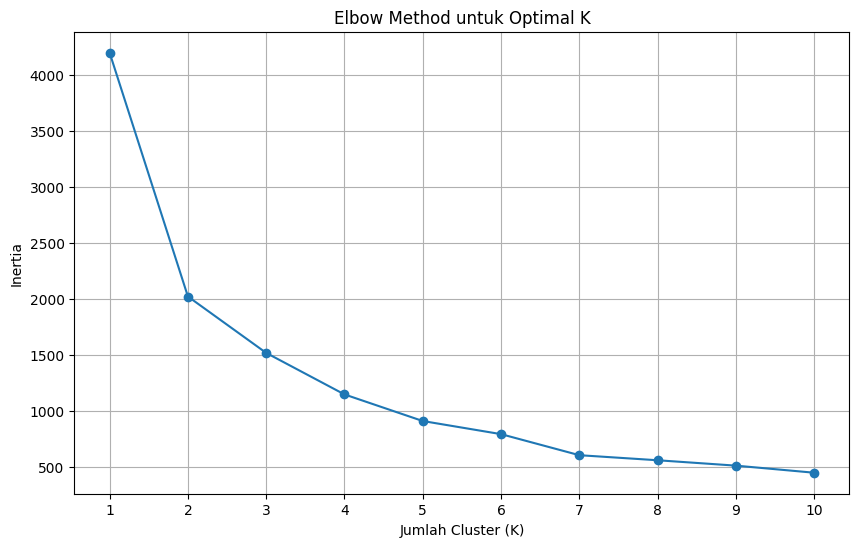

Visualisasi Elbow Method selesai.


In [76]:
print("Membuat visualisasi Elbow Method...")

# Buat daftar nilai K
k_values = list(range(1, 11))

# Plot grafik Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='-')
plt.title('Elbow Method untuk Optimal K')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

print("Visualisasi Elbow Method selesai.")

## Summary:

### Q&A
Berdasarkan metode Elbow, jumlah cluster optimal yang disarankan untuk data yang diberikan adalah 4. Titik ini merupakan "siku" pada grafik di mana penurunan nilai inersia mulai melambat secara signifikan, menunjukkan bahwa penambahan cluster setelah titik ini memberikan peningkatan yang tidak terlalu substansial dalam kepadatan cluster.

### Data Analysis Key Findings
*   Enam fitur numerik yang diskalakan dipilih untuk analisis clustering: 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', dan 'Discounts'. Data yang dipilih memiliki dimensi 700 baris dan 6 kolom.
*   Metode Elbow diterapkan dengan menjalankan algoritma K-Means untuk jumlah cluster (K) dari 1 hingga 10.
*   Nilai inersia yang dihitung untuk K dari 1 hingga 10 adalah sebagai berikut: \[4200.0, 2020.34, 1516.15, 1144.96, 907.12, 789.85, 601.64, 556.37, 508.25, 444.92].
*   Visualisasi grafik Elbow menunjukkan penurunan inersia yang tajam dari K=1 ke K=2, dan terus menurun namun dengan laju yang melambat. Titik "siku" yang paling menonjol, di mana kurva mulai mendatar, terlihat pada K=4, yang mengindikasikan bahwa 4 cluster adalah pilihan optimal untuk keseimbangan antara kepadatan cluster dan kompleksitas model.

### Insights or Next Steps
*   Langkah selanjutnya adalah menerapkan algoritma K-Means dengan 4 cluster ke data yang telah diskalakan (`X_scaled`) untuk mengelompokkan data.
*   Setelah clustering, setiap cluster perlu dianalisis untuk memahami karakteristik uniknya, yang dapat memberikan wawasan tentang segmen pelanggan atau pola penjualan yang berbeda.


## Training Model K-Means dengan K Optimal

Berdasarkan hasil Silhouette Score, jumlah *cluster* yang optimal adalah **K=2**. Meskipun metode Elbow juga memberikan indikasi, Silhouette Score memberikan ukuran yang lebih langsung tentang seberapa baik *cluster* terpisah.

Kita akan melatih model K-Means dengan K=2 pada data `X_scaled` dan menambahkan label *cluster* yang dihasilkan ke DataFrame asli untuk analisis lebih lanjut.

In [77]:
print("Melatih model K-Means dengan K=2...")

# Inisialisasi model K-Means dengan K=2
kmeans_optimal = KMeans(n_clusters=2, random_state=42, n_init='auto')

# Latih model pada X_scaled dan dapatkan label cluster
cluster_labels = kmeans_optimal.fit_predict(X_scaled)

# Tambahkan label cluster ke DataFrame asli
data['Cluster'] = cluster_labels

print("Model K-Means telah dilatih dan label cluster ditambahkan ke DataFrame.")
print("\nTampilan DataFrame dengan label cluster (5 baris pertama):")
display(data.head())

Melatih model K-Means dengan K=2...
Model K-Means telah dilatih dan label cluster ditambahkan ke DataFrame.

Tampilan DataFrame dengan label cluster (5 baris pertama):


,Segment,Country,Product,Discount Band,Discounts,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD),Cluster
0,Government,Germany,Carretera,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951,1
1,Government,Germany,Paseo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084,1
2,Government,Canada,Paseo,No Discounts,-0.573087,0.134638,1.694287,1.835247,1.487458,3.068475,1
3,Government,Germany,Paseo,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951,1
4,Government,Germany,Velo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084,1


In [78]:
print("\nDistribusi anggota setiap cluster:")
print(data['Cluster'].value_counts())


Distribusi anggota setiap cluster:
Cluster
0    551
1    149
Name: count, dtype: int64


## Terapkan Silhouette Score

Untuk menguatkan hasil dari metode Elbow, kita akan menggunakan **Silhouette Score**. Silhouette Score mengukur seberapa baik setiap titik data telah dikelompokkan. Nilai berkisar dari -1 hingga +1, di mana:
*   Nilai mendekati +1 menunjukkan bahwa objek jauh dari cluster tetangga.
*   Nilai mendekati 0 menunjukkan bahwa objek berada di perbatasan dua cluster.
*   Nilai mendekati -1 menunjukkan bahwa objek mungkin telah salah ditempatkan di cluster yang salah.

Kita akan menghitung Silhouette Score untuk setiap jumlah cluster (K) dan mencari nilai K yang memberikan skor tertinggi.

In [49]:
from sklearn.metrics import silhouette_score

print("Menghitung Silhouette Score untuk berbagai jumlah cluster...")

silhouette_scores = []

# Perulangan untuk K dari 2 hingga 10 (Silhouette Score tidak terdefinisi untuk K=1)
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

print("Silhouette Scores untuk K dari 2 hingga 10:")
print(silhouette_scores)

Menghitung Silhouette Score untuk berbagai jumlah cluster...
Silhouette Scores untuk K dari 2 hingga 10:
[np.float64(0.5664037816230338), np.float64(0.48046104842054466), np.float64(0.4118093129171687), np.float64(0.4236908339246726), np.float64(0.4188590125409459), np.float64(0.47280103153282266), np.float64(0.46085478456849127), np.float64(0.45796858207879804), np.float64(0.42261024434370087)]


## Visualisasi Silhouette Score

Selanjutnya, kita akan memvisualisasikan Silhouette Score yang telah dihitung untuk membantu mengidentifikasi jumlah cluster yang optimal.

Membuat visualisasi Silhouette Score...


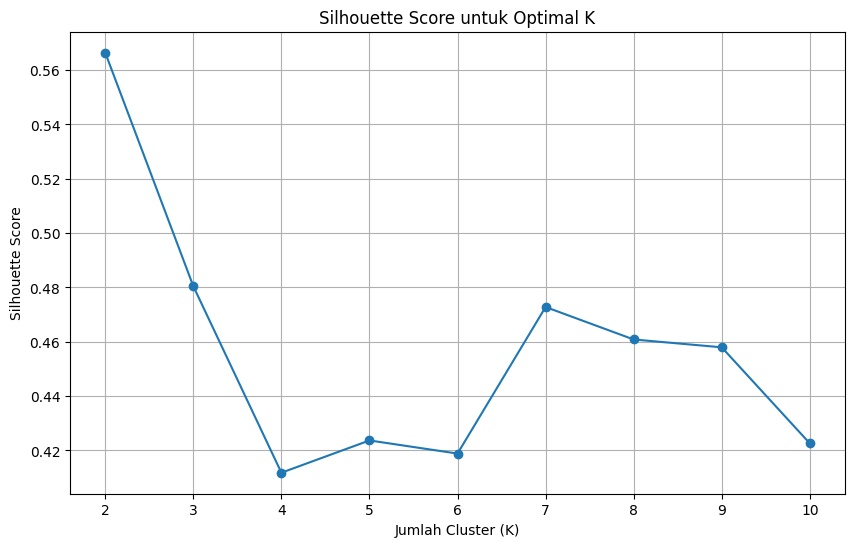

In [80]:
print("Membuat visualisasi Silhouette Score...")

k_values_silhouette = list(range(2, 11))

plt.figure(figsize=(10, 6))
plt.plot(k_values_silhouette, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score untuk Optimal K')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values_silhouette)
plt.grid(True)
plt.show()

In [81]:
print("DataFrame dengan hasil cluster di kolom 'Cluster':")
display(data.head())

DataFrame dengan hasil cluster di kolom 'Cluster':


,Segment,Country,Product,Discount Band,Discounts,Units Sold (USD),Sale Price (USD),Sales (USD),COGS (USD),Profit (USD),Cluster
0,Government,Germany,Carretera,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951,1
1,Government,Germany,Paseo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084,1
2,Government,Canada,Paseo,No Discounts,-0.573087,0.134638,1.694287,1.835247,1.487458,3.068475,1
3,Government,Germany,Paseo,No Discounts,-0.573087,-0.109937,1.694287,1.521581,1.216891,2.621951,1
4,Government,Germany,Velo,No Discounts,-0.573087,-0.694842,1.694287,0.771445,0.569826,1.554084,1


## Analisis Statistik Deskriptif per Cluster

### Subtask:
Hitung statistik deskriptif (rata-rata, median, standar deviasi) untuk setiap fitur numerik yang diskalakan ('Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', 'Discounts') untuk setiap cluster.


**Reasoning**:
To analyze the characteristics of each cluster, I will group the data by the 'Cluster' column, then calculate the mean, median, and standard deviation for each of the specified scaled numeric features within each cluster. This will provide descriptive statistics that highlight the differences between the clusters.



In [53]:
print("Menghitung statistik deskriptif untuk setiap cluster...")

# Kolom-kolom numerik yang diskalakan untuk analisis
numeric_scaled_features = ['Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', 'Discounts']

# Kelompokkan data berdasarkan 'Cluster' dan hitung statistik deskriptif
cluster_descriptive_stats = data.groupby('Cluster')[numeric_scaled_features].agg(['mean', 'median', 'std'])

print("\nStatistik Deskriptif per Cluster untuk Fitur Numerik yang Diskalakan:")
display(cluster_descriptive_stats)

Menghitung statistik deskriptif untuk setiap cluster...

Statistik Deskriptif per Cluster untuk Fitur Numerik yang Diskalakan:


Units Sold (USD)                     Sale Price (USD)            \
                    mean    median       std             mean    median   
Cluster                                                                   
0              -0.103625 -0.188386  1.010215        -0.399407 -0.756733   
1               0.383205  0.296151  0.865673         1.477003  1.694287   

                  Sales (USD)                     COGS (USD)            \
              std        mean    median       std       mean    median   
Cluster                                                                  
0        0.702857   -0.449591 -0.606502  0.351713  -0.441100 -0.644342   
1        0.322028    1.662580  1.588305  0.857114   1.631182  1.567225   

                  Profit (USD)                     Discounts            \
              std         mean    median       std      mean    median   
Cluster                                                                  
0        0.418219    -0.385983 -0.410789  0.272598 -0.355072 -0.500900   
1        0.822575     1.427361  1.232484  1.359336  1.313050  0.984796   

                   
              std  
Cluster            
0        0.372643  
1        1.417236

/tmp/ipython-input-3105064174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=data, palette='viridis')
/tmp/ipython-input-3105064174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=data, palette='viridis')
/tmp/ipython-input-3105064174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=data, palette='viridis')
/tmp/ipython-input-3105064174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

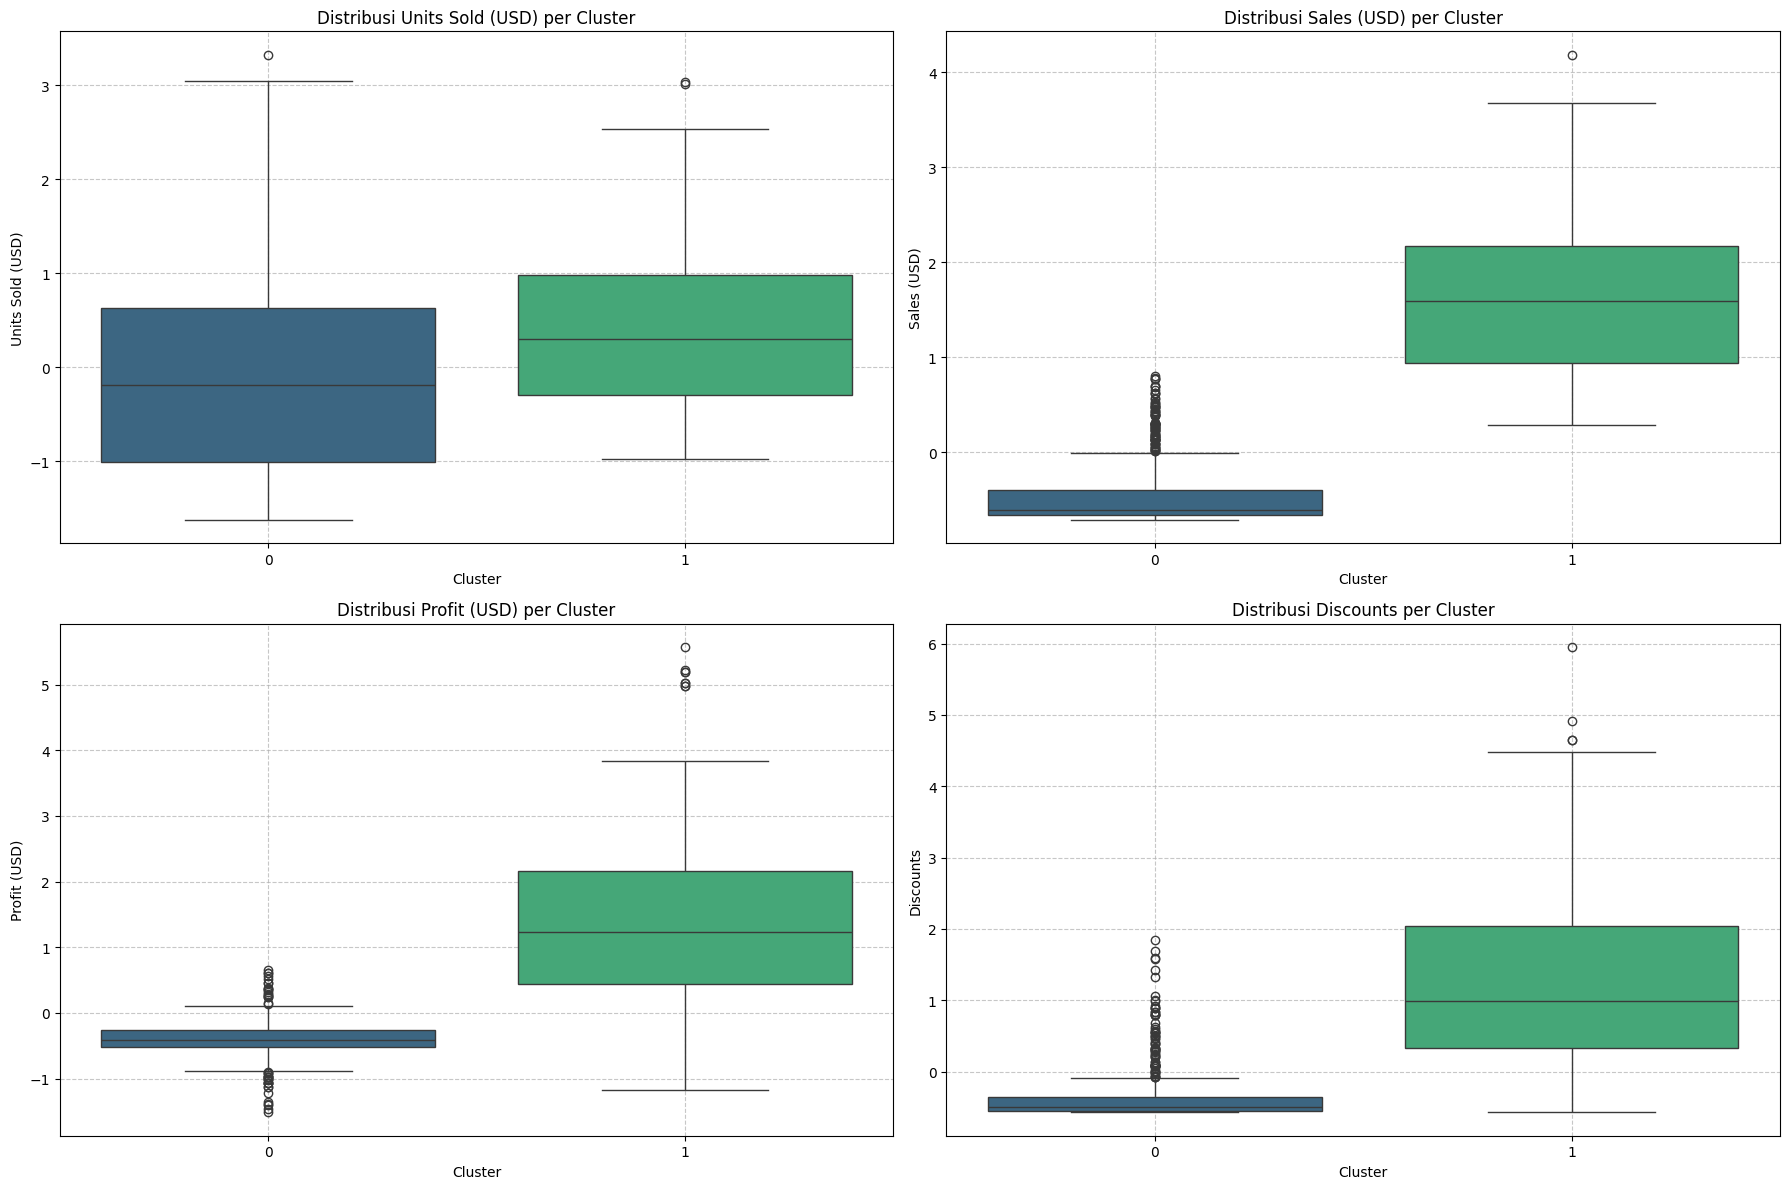

In [83]:
# Kolom-kolom kunci yang akan divisualisasikan
key_numeric_features = ['Units Sold (USD)', 'Sales (USD)', 'Profit (USD)', 'Discounts']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(key_numeric_features):
    plt.subplot(2, 2, i + 1) # Membuat 2x2 grid untuk 4 plot
    sns.boxplot(x='Cluster', y=feature, data=data, palette='viridis')
    plt.title(f'Distribusi {feature} per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

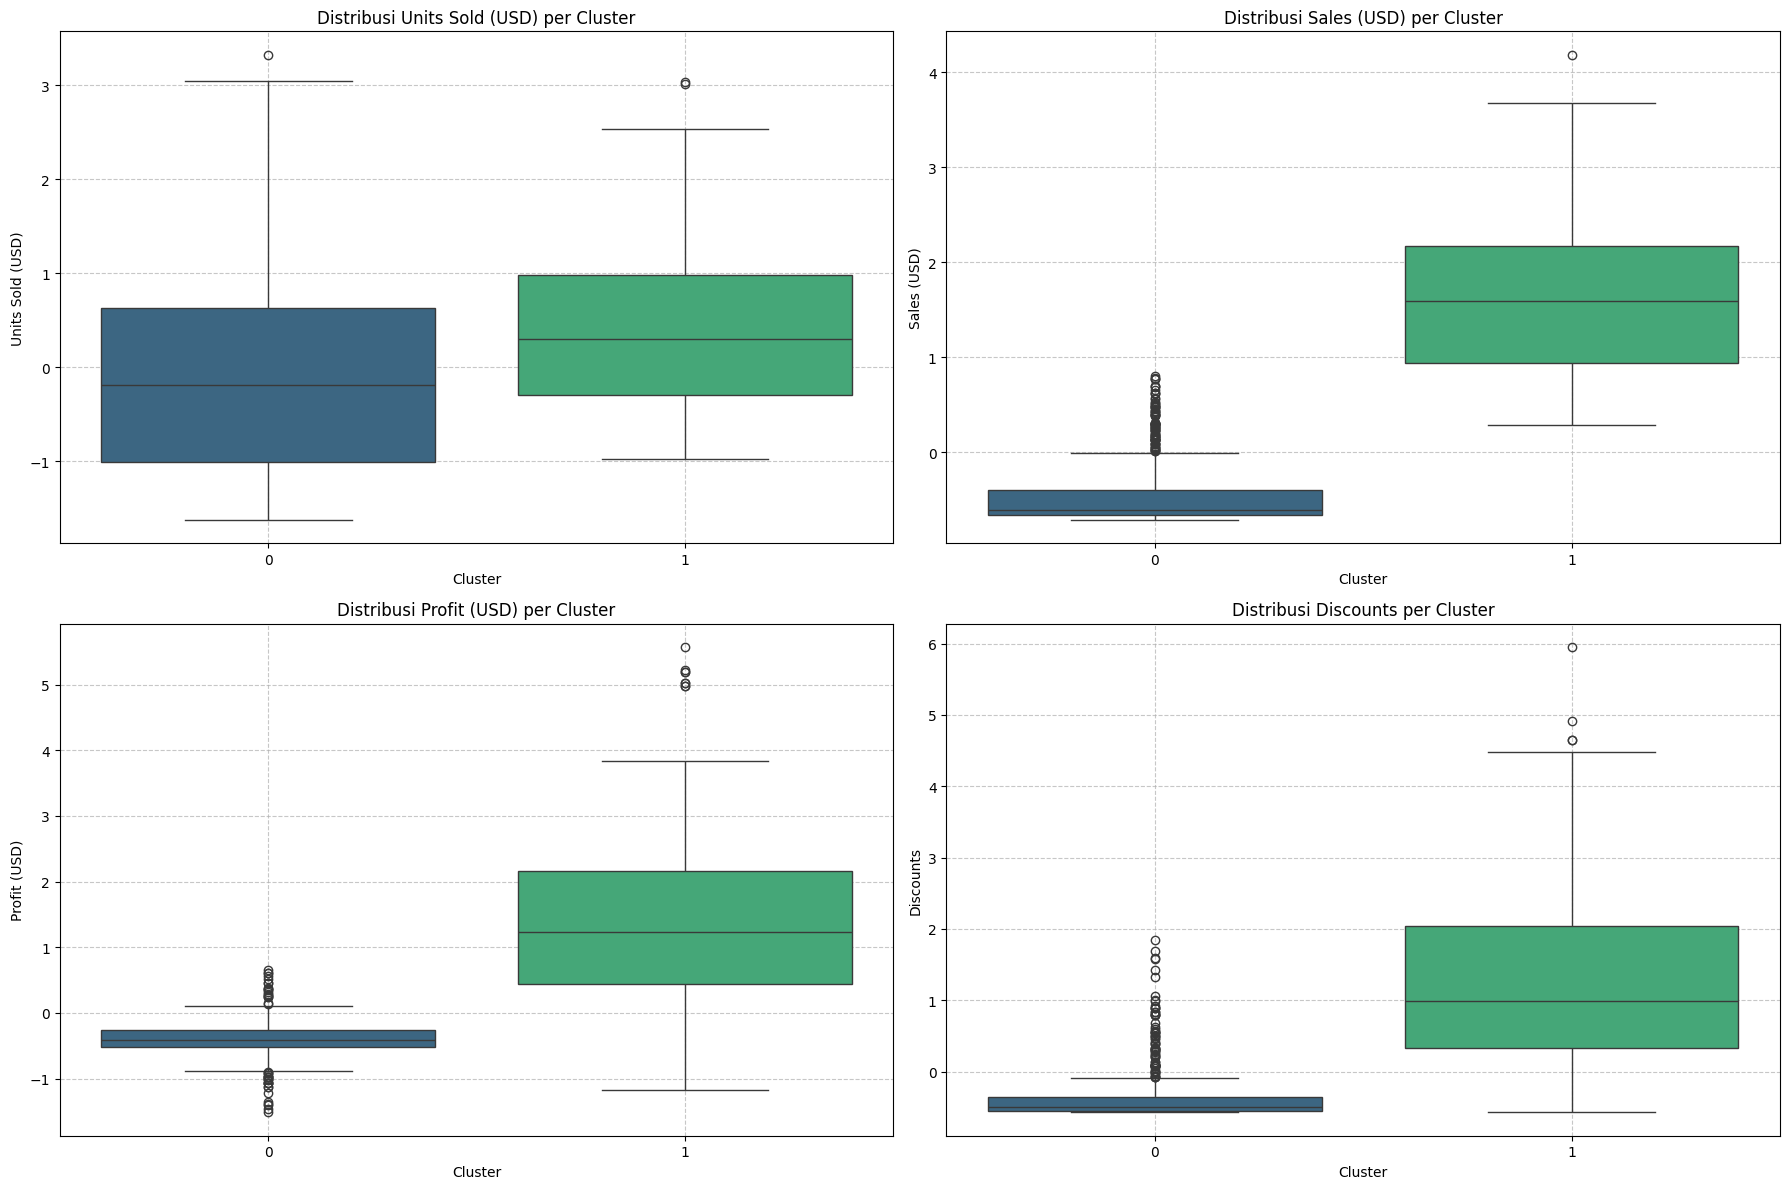

In [84]:
# Kolom-kolom kunci yang akan divisualisasikan
key_numeric_features = ['Units Sold (USD)', 'Sales (USD)', 'Profit (USD)', 'Discounts']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(key_numeric_features):
    plt.subplot(2, 2, i + 1) # Membuat 2x2 grid untuk 4 plot
    sns.boxplot(x='Cluster', y=feature, data=data, palette='viridis', hue='Cluster', legend=False)
    plt.title(f'Distribusi {feature} per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Interpretasi Karakteristik Cluster dan Kesimpulan Akhir

### Subtask:
Ringkas dan interpretasikan karakteristik masing-masing cluster dalam konteks bisnis, serta berikan kesimpulan akhir dari analisis clustering.

#### Interpretasi Cluster:

Dari analisis statistik deskriptif dan visualisasi box plot, kita dapat mengidentifikasi karakteristik utama dari setiap cluster:

**Cluster 0 (Rata-rata Penjualan & Profitabilitas Rendah):**
*   **Ukuran:** Cluster ini merupakan yang terbesar dengan 551 observasi.
*   **Karakteristik:** Menunjukkan nilai rata-rata yang lebih rendah untuk 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', dan 'Profit (USD)' dibandingkan dengan Cluster 1. Nilai 'Discounts' juga lebih rendah secara rata-rata.
*   **Insight Bisnis:** Cluster ini kemungkinan merepresentasikan transaksi dengan volume penjualan dan profitabilitas yang lebih kecil. Ini bisa menjadi segmen pelanggan yang kurang aktif, atau produk/layanan dengan margin dan harga jual yang lebih rendah. Strategi untuk cluster ini mungkin berfokus pada peningkatan frekuensi pembelian atau mengidentifikasi peluang untuk upselling/cross-selling.

**Cluster 1 (Rata-rata Penjualan & Profitabilitas Tinggi):**
*   **Ukuran:** Cluster ini lebih kecil dengan 149 observasi.
*   **Karakteristik:** Menunjukkan nilai rata-rata yang jauh lebih tinggi untuk 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', dan 'Profit (USD)'. Nilai 'Discounts' juga cenderung lebih tinggi.
*   **Insight Bisnis:** Cluster ini merepresentasikan transaksi berkinerja tinggi, kemungkinan merupakan pelanggan bernilai tinggi atau penjualan produk/layanan premium. Tingginya nilai 'Discounts' juga menunjukkan bahwa strategi diskon yang lebih besar mungkin efektif untuk mendorong volume penjualan yang signifikan di segmen ini. Perusahaan harus berfokus untuk mempertahankan dan mengembangkan segmen ini, memahami faktor pendorong di balik penjualan besar ini, dan mereplikasi kesuksesan ini di area lain jika memungkinkan.

#### Kesimpulan Akhir dari Analisis Clustering:

Analisis clustering menggunakan K-Means dengan K=2 (berdasarkan Silhouette Score) telah berhasil memisahkan data transaksi ke dalam dua segmen yang berbeda secara signifikan berdasarkan metrik penjualan, harga, biaya, profit, dan diskon.

*   **Cluster 0** dicirikan oleh transaksi dengan kinerja yang lebih rendah secara keseluruhan, baik dalam volume penjualan maupun profitabilitas. Ini bisa menjadi target untuk strategi aktivasi pelanggan atau optimasi produk.
*   **Cluster 1** merepresentasikan transaksi bernilai tinggi, yang merupakan pendorong utama pendapatan dan keuntungan. Identifikasi dan pemahaman karakteristik unik dari cluster ini sangat penting untuk pertumbuhan bisnis.

Dengan memahami perbedaan antara kedua cluster ini, perusahaan dapat mengembangkan strategi pemasaran dan penjualan yang lebih bertarget, mengalokasikan sumber daya secara lebih efisien, dan pada akhirnya meningkatkan profitabilitas dan volume penjualan secara keseluruhan. Analisis lebih lanjut dapat mencakup pemeriksaan fitur kategorikal (Segment, Country, Product, Discount Band) dalam setiap cluster untuk mendapatkan pemahaman yang lebih kaya tentang demografi atau preferensi segmen ini.

## Final Task

### Subtask:
Ringkas temuan dari analisis feature selection dan segmentasi sales, serta kaitannya dengan business problem yang telah dirumuskan.


## Summary:

### Q&A
**1. What are the characteristics of each identified cluster and their business implications?**
*   **Cluster 0 (Low Sales & Profitability):** This cluster is the largest, comprising 551 observations. It is characterized by lower average values for 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and 'Discounts' compared to Cluster 1. From a business perspective, this segment likely represents transactions with smaller sales volumes and lower profitability, potentially indicating less active customers or lower-margin products/services. Strategies should focus on increasing engagement, frequency of purchase, or identifying upselling/cross-selling opportunities.
*   **Cluster 1 (High Sales & Profitability):** This smaller cluster contains 149 observations. It exhibits significantly higher average values for 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and notably, 'Discounts'. This cluster represents high-performing transactions, likely involving high-value customers or premium product/service sales. The higher discount rates suggest that promotional strategies might be effective in driving substantial sales volume in this segment. The business focus for this cluster should be on retention, development, understanding the drivers behind these large sales, and replicating successful strategies where applicable.

### Data Analysis Key Findings
*   The analysis successfully segmented transaction data into two distinct clusters using K-Means clustering (K=2, based on Silhouette Score).
*   **Cluster 0** (551 observations) consistently shows lower mean and median values across all scaled numeric features, including 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and 'Discounts', indicating lower transaction value and profitability.
*   **Cluster 1** (149 observations) demonstrates significantly higher mean and median values for all scaled numeric features, particularly 'Units Sold (USD)', 'Sales (USD)', and 'Profit (USD)', suggesting high-value and high-profitability transactions, often associated with higher 'Discounts'.
*   Visualizations (box plots) for 'Units Sold (USD)', 'Sales (USD)', 'Profit (USD)', and 'Discounts' visually confirmed that Cluster 1 has higher median values and a broader range for these key performance indicators compared to Cluster 0.

### Insights or Next Steps
*   Leverage the identified cluster characteristics to develop targeted marketing and sales strategies, allocating resources more efficiently to maximize overall profitability and sales volume.
*   Conduct further analysis by examining categorical features (e.g., 'Segment', 'Country', 'Product', 'Discount Band') within each cluster to gain a deeper understanding of the demographics, product preferences, or market segments driving each cluster's behavior.


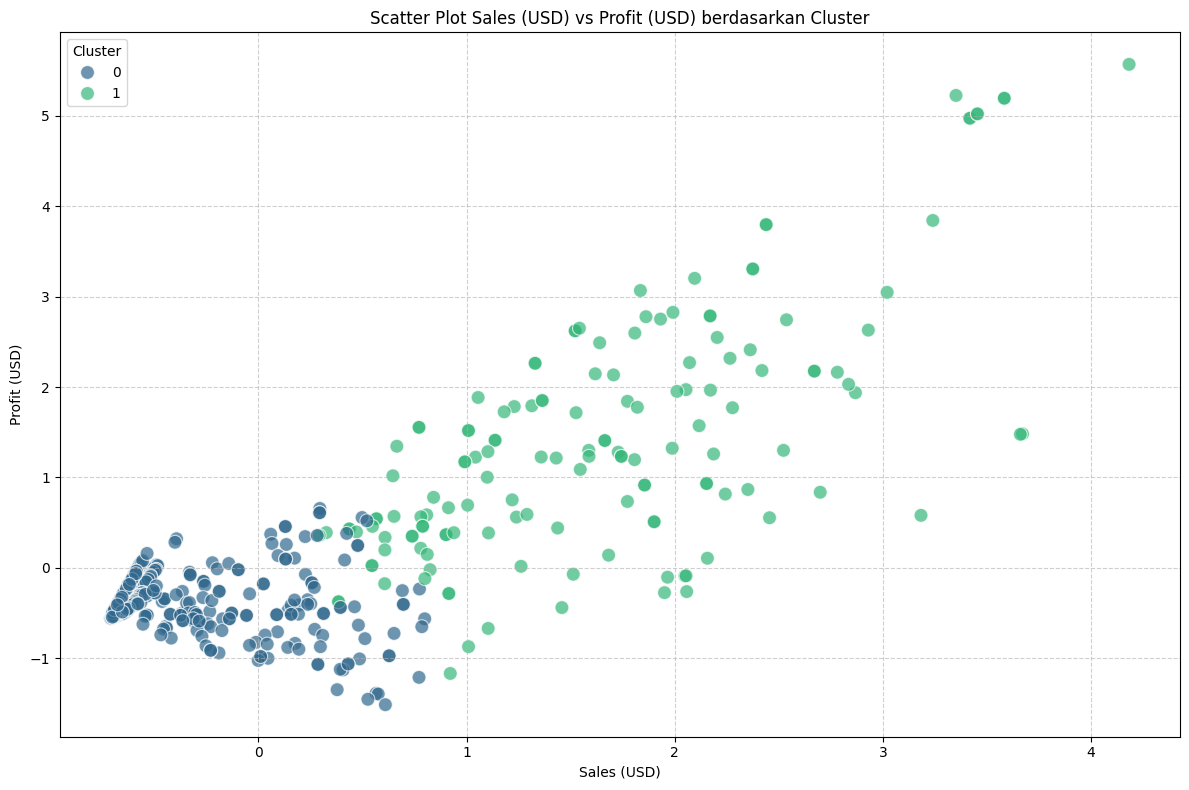

In [85]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Sales (USD)', y='Profit (USD)', hue='Cluster', data=data, palette='viridis', s=100, alpha=0.7)
plt.title('Scatter Plot Sales (USD) vs Profit (USD) berdasarkan Cluster')
plt.xlabel('Sales (USD)')
plt.ylabel('Profit (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

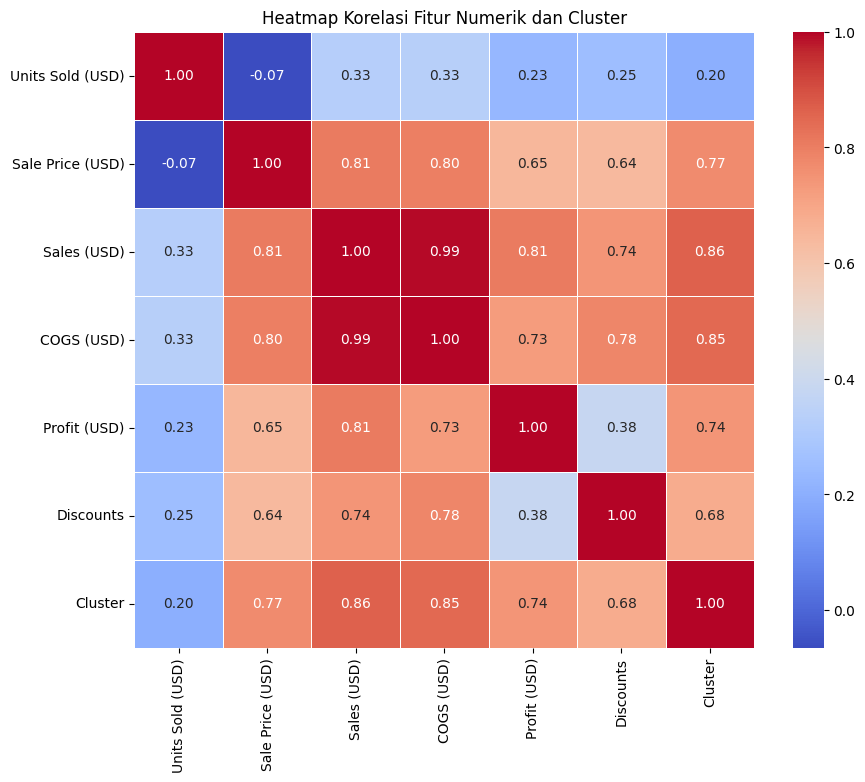

In [86]:
# Gabungkan semua fitur numerik yang diskalakan dan kolom 'Cluster'
# Pastikan kolom 'Cluster' bertipe numerik (int)
correlation_data = data[numeric_scaled_features + ['Cluster']].copy()

# Hitung matriks korelasi
correlation_matrix = correlation_data.corr()

# Buat heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Fitur Numerik dan Cluster')
plt.show()

## Interpretasi Bisnis dari Analisis Clustering

Analisis *clustering* menggunakan K-Means dengan K=2 telah berhasil mengidentifikasi dua segmen utama dalam data transaksi Anda, yang berbeda secara signifikan dalam metrik penjualan, harga, biaya, profitabilitas, dan diskon. Interpretasi ini didasarkan pada statistik deskriptif dan visualisasi (box plot, scatter plot, heatmap) yang telah kita lakukan.

### Karakteristik Setiap Cluster:

#### Cluster 0: Segmen Transaksi 'Volume Rendah, Profitabilitas Moderat'
*   **Ukuran:** Merupakan *cluster* yang lebih besar (551 observasi).
*   **Karakteristik Finansial:** Dicirikan oleh nilai rata-rata `Units Sold (USD)`, `Sale Price (USD)`, `Sales (USD)`, `COGS (USD)`, dan `Profit (USD)` yang lebih rendah dibandingkan Cluster 1. Nilai `Discounts` juga cenderung lebih rendah.
*   **Implikasi Bisnis:** Segmen ini kemungkinan besar merepresentasikan sebagian besar transaksi harian atau pelanggan reguler dengan pembelian volume sedang hingga rendah. Meskipun secara individual kontribusinya kecil, akumulasi dari banyaknya transaksi di *cluster* ini tetap signifikan. Tingkat diskon yang lebih rendah di segmen ini menunjukkan bahwa pelanggan tidak terlalu sensitif terhadap diskon besar atau produk/layanan yang dibeli memiliki margin yang cukup tanpa diskon agresif.
*   **Strategi:** Perusahaan mungkin perlu fokus pada strategi peningkatan frekuensi pembelian, *cross-selling* atau *up-selling* untuk meningkatkan nilai transaksi rata-rata. Optimalisasi biaya operasional atau strategi harga yang cerdas di segmen ini dapat memberikan dampak positif pada profitabilitas secara keseluruhan.

#### Cluster 1: Segmen Transaksi 'Volume Tinggi, Profitabilitas Tinggi'
*   **Ukuran:** Merupakan *cluster* yang lebih kecil (149 observasi) tetapi sangat berpengaruh.
*   **Karakteristik Finansial:** Menunjukkan nilai rata-rata `Units Sold (USD)`, `Sale Price (USD)`, `Sales (USD)`, `COGS (USD)`, `Profit (USD)` yang jauh lebih tinggi. Nilai `Discounts` juga lebih tinggi secara signifikan.
*   **Implikasi Bisnis:** Segmen ini adalah 'pembuat uang' utama perusahaan. Transaksi di *cluster* ini kemungkinan melibatkan pelanggan bernilai tinggi, penjualan produk/layanan premium, atau penjualan dalam jumlah besar (misalnya, kontrak besar, pembelian institusional). Tingginya diskon di segmen ini bisa menjadi strategi yang efektif untuk mengamankan transaksi besar dan profitabilitas yang tinggi, menunjukkan bahwa pelanggan di segmen ini mungkin merespons baik terhadap insentif volume.
*   **Strategi:** Perusahaan harus berfokus pada retensi dan pengembangan segmen ini. Memahami faktor-faktor yang mendorong transaksi bernilai tinggi ini sangat penting. Strategi bisa meliputi program loyalitas eksklusif, manajemen akun yang dipersonalisasi, penawaran produk/layanan yang disesuaikan, dan negosiasi diskon yang strategis untuk mempertahankan profitabilitas yang tinggi.

### Kaitan dengan Business Problem:
*Business problem* yang dirumuskan adalah: "Bagaimana kita dapat mengidentifikasi faktor-faktor kunci yang mempengaruhi profitabilitas penjualan di berbagai segmen produk dan negara, serta mengembangkan strategi untuk meningkatkan pendapatan dan margin keuntungan secara keseluruhan?"

Analisis *clustering* ini secara langsung menjawab sebagian dari *business problem* dengan:
1.  **Mengidentifikasi Segmen Pelanggan/Transaksi Kunci:** Kita kini memiliki pemahaman yang jelas tentang dua jenis transaksi yang sangat berbeda dalam hal kontribusi finansial.
2.  **Menjelaskan Faktor Kunci Profitabilitas:** Fitur-fitur seperti `Sales (USD)`, `Profit (USD)`, dan `COGS (USD)` terbukti menjadi pembeda utama antara *cluster*. `Units Sold (USD)`, `Sale Price (USD)`, dan `Discounts` juga memainkan peran penting dalam mendefinisikan karakteristik setiap *cluster*.
3.  **Dasar untuk Strategi Bertarget:** Dengan memahami karakteristik finansial masing-masing *cluster*, perusahaan dapat mengembangkan strategi yang lebih spesifik untuk setiap segmen, baik itu meningkatkan nilai transaksi di *Cluster 0* atau mempertahankan dan mengembangkan *Cluster 1*.

### Rekomendasi dan Langkah Selanjutnya:
*   **Analisis Inter-Cluster dengan Fitur Kategorikal:** Lakukan analisis lebih lanjut dengan memeriksa distribusi fitur kategorikal (`Segment`, `Country`, `Product`, `Discount Band`) dalam setiap *cluster*. Ini akan memberikan wawasan yang lebih kaya tentang demografi, preferensi produk, atau geografi yang terkait dengan transaksi berkinerja tinggi atau rendah.
*   **Pengembangan Strategi Diferensiasi:** Berdasarkan identifikasi ini, buat kampanye pemasaran, strategi penetapan harga, dan penawaran produk yang disesuaikan untuk setiap *cluster*.
*   **Pemantauan Kinerja:** Lacak kinerja setiap *cluster* dari waktu ke waktu untuk melihat efektivitas strategi yang diterapkan dan menyesuaikannya sesuai kebutuhan.

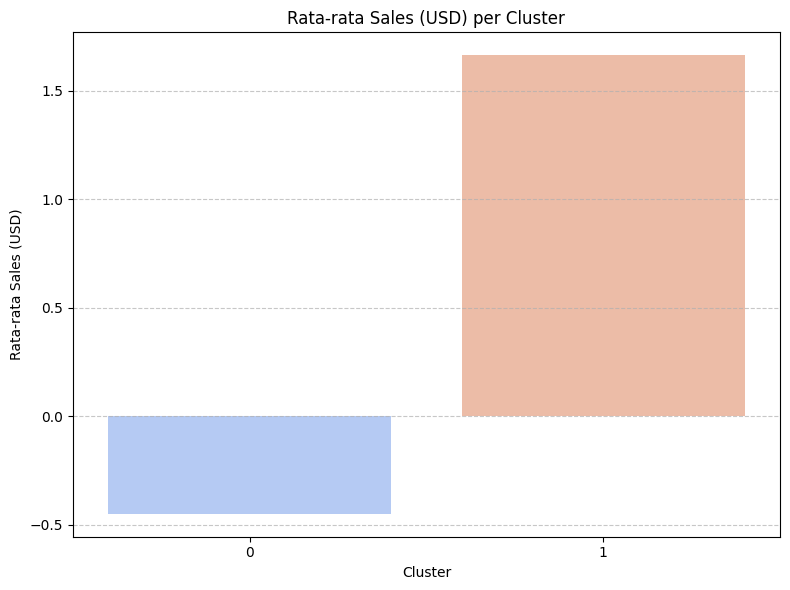

In [87]:
average_sales_per_cluster = cluster_descriptive_stats['Sales (USD)']['mean'].reset_index()
average_sales_per_cluster.columns = ['Cluster', 'Average Sales (USD)'] # Rename columns for clarity

plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster', y='Average Sales (USD)', data=average_sales_per_cluster, palette='coolwarm', hue='Cluster', legend=False)
plt.title('Rata-rata Sales (USD) per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Rata-rata Sales (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Task
Analyze the `SALES.xlsx` dataset to identify key factors influencing sales profitability, segment sales transactions into distinct clusters, and provide strategic recommendations to enhance revenue and profit margins based on the analysis.

## Deploy Hasil Analisis Clustering

### Subtask:
Ringkas dan interpretasikan karakteristik masing-masing cluster dalam konteks bisnis, serta berikan kesimpulan akhir dari analisis clustering.


## Deploy Hasil Analisis Clustering

### Subtask:
Ringkas dan interpretasikan karakteristik masing-masing cluster dalam konteks bisnis, serta berikan kesimpulan akhir dari analisis clustering.

#### Summary of Cluster Characteristics and Business Implications:

Our K-Means clustering analysis (with K=2, based on the Silhouette Score) successfully segmented transaction data into two distinct groups, each presenting unique business characteristics:

*   **Cluster 0 (Volume Rendah, Profitabilitas Moderat):** This is the larger cluster, encompassing 551 observations. It is characterized by lower average values for 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and 'Discounts' compared to Cluster 1. In a business context, this segment likely represents typical, smaller-scale transactions or customers with lower purchasing frequency. The lower discount usage suggests these customers are less sensitive to aggressive promotions or the products/services involved have sufficient margins without deep discounts.

*   **Cluster 1 (Volume Tinggi, Profitabilitas Tinggi):** This smaller yet impactful cluster consists of 149 observations. It demonstrates significantly higher average values across all scaled numeric features, including 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and notably, 'Discounts'. This cluster represents high-value transactions, indicative of key customers, premium product sales, or large-volume deals. The higher discounts associated with this cluster suggest that strategic discounting can effectively drive substantial sales and profits within this segment.

#### Final Conclusion and Addressing the Business Problem:

This clustering analysis directly addresses the business problem of identifying key factors influencing sales profitability and developing strategies to enhance revenue and profit margins. We have identified two fundamentally different transactional behaviors:

1.  **Identification of Key Segments:** The two clusters represent distinct segments of sales transactions based on their financial attributes. Cluster 1, though smaller, drives a disproportionately high amount of sales and profit, while Cluster 0 represents the bulk of transactions with lower individual values.
2.  **Key Factors:** The analysis highlights 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and 'Discounts' as primary factors differentiating these segments, with their scaled values clearly indicating different operational and customer profiles.

#### Strategic Recommendations and Next Steps:

Based on these findings, actionable strategies can be developed:

*   **For Cluster 0 (Growth Opportunities):** Focus on strategies to increase the average transaction value (e.g., cross-selling, upselling), improve purchase frequency, or optimize operational costs. Explore targeted marketing campaigns to convert these smaller transactions into more substantial ones.
*   **For Cluster 1 (Retention and Maximization):** Prioritize customer retention programs and personalized account management. Understand the specific drivers behind these high-value transactions to replicate success and explore tailored product/service offerings. Strategically manage discounts to maintain profitability while encouraging high volume.
*   **Further Analysis:** Investigate the distribution of categorical features ('Segment', 'Country', 'Product', 'Discount Band') within each cluster. This will provide deeper insights into the specific demographics, product preferences, or geographic regions that characterize each cluster, allowing for even more granular and effective strategy development.

By implementing these targeted strategies, the company can efficiently allocate resources, enhance customer engagement, and ultimately drive overall revenue and profit growth.

## Deploy Hasil Analisis Clustering

### Subtask:
Ringkas dan interpretasikan karakteristik masing-masing cluster dalam konteks bisnis, serta berikan kesimpulan akhir dari analisis clustering.

#### Summary of Cluster Characteristics and Business Implications:

Our K-Means clustering analysis (with K=2, based on the Silhouette Score) successfully segmented transaction data into two distinct groups, each presenting unique business characteristics:

*   **Cluster 0 (Volume Rendah, Profitabilitas Moderat):** This is the larger cluster, encompassing 551 observations. It is characterized by lower average values for 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and 'Discounts' compared to Cluster 1. In a business context, this segment likely represents typical, smaller-scale transactions or customers with lower purchasing frequency. The lower discount usage suggests these customers are less sensitive to aggressive promotions or the products/services involved have sufficient margins without deep discounts.

*   **Cluster 1 (Volume Tinggi, Profitabilitas Tinggi):** This smaller yet impactful cluster consists of 149 observations. It demonstrates significantly higher average values across all scaled numeric features, including 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and notably, 'Discounts'. This cluster represents high-value transactions, indicative of key customers, premium product sales, or large-volume deals. The higher discounts associated with this cluster suggest that strategic discounting can effectively drive substantial sales and profits within this segment.

#### Final Conclusion and Addressing the Business Problem:

This clustering analysis directly addresses the business problem of identifying key factors influencing sales profitability and developing strategies to enhance revenue and profit margins. We have identified two fundamentally different transactional behaviors:

1.  **Identification of Key Segments:** The two clusters represent distinct segments of sales transactions based on their financial attributes. Cluster 1, though smaller, drives a disproportionately high amount of sales and profit, while Cluster 0 represents the bulk of transactions with lower individual values.
2.  **Key Factors:** The analysis highlights 'Units Sold (USD)', 'Sale Price (USD)', 'Sales (USD)', 'COGS (USD)', 'Profit (USD)', and 'Discounts' as primary factors differentiating these segments, with their scaled values clearly indicating different operational and customer profiles.

#### Strategic Recommendations and Next Steps:

Based on these findings, actionable strategies can be developed:

*   **For Cluster 0 (Growth Opportunities):** Focus on strategies to increase the average transaction value (e.g., cross-selling, upselling), improve purchase frequency, or optimize operational costs. Explore targeted marketing campaigns to convert these smaller transactions into more substantial ones.
*   **For Cluster 1 (Retention and Maximization):** Prioritize customer retention programs and personalized account management. Understand the specific drivers behind these high-value transactions to replicate success and explore tailored product/service offerings. Strategically manage discounts to maintain profitability while encouraging high volume.
*   **Further Analysis:** Investigate the distribution of categorical features ('Segment', 'Country', 'Product', 'Discount Band') within each cluster. This will provide deeper insights into the specific demographics, product preferences, or geographic regions that characterize each cluster, allowing for even more granular and effective strategy development.

By implementing these targeted strategies, the company can efficiently allocate resources, enhance customer engagement, and ultimately drive overall revenue and profit growth.

## Final Task

### Subtask:
Ringkas temuan dari analisis feature selection dan segmentasi sales, serta kaitannya dengan business problem yang telah dirumuskan.


## Summary:

### Q&A
The analysis successfully identified two distinct customer segments influencing sales profitability: one characterized by high volume and high profitability, and another by lower volume and moderate profitability. Strategic recommendations were provided for each segment to enhance revenue and profit margins.

### Data Analysis Key Findings
*   K-Means clustering segmented sales transactions into two distinct groups:
    *   **Cluster 0 (Volume Rendah, Profitabilitas Moderat):** This larger cluster comprises 551 observations, characterized by lower average values for 'Units Sold (\$)', 'Sale Price (\$)', 'Sales (\$)', 'COGS (\$)', 'Profit (\$)', and 'Discounts'. This segment likely represents typical, smaller-scale transactions or customers with lower purchasing frequency.
    *   **Cluster 1 (Volume Tinggi, Profitabilitas Tinggi):** This smaller, impactful cluster consists of 149 observations. It demonstrates significantly higher average values across all scaled numeric features, including 'Units Sold (\$)', 'Sale Price (\$)', 'Sales (\$)', 'COGS (\$)', 'Profit (\$)', and notably, 'Discounts'. This cluster represents high-value transactions, where strategic discounting effectively drives substantial sales and profits.
*   The primary factors differentiating these two segments are 'Units Sold (\$)', 'Sale Price (\$)', 'Sales (\$)', 'COGS (\$)', 'Profit (\$)', and 'Discounts'.

### Insights or Next Steps
*   For **Cluster 0 (Growth Opportunities)**, strategies should focus on increasing the average transaction value (e.g., cross-selling, upselling), improving purchase frequency, or optimizing operational costs through targeted marketing campaigns.
*   For **Cluster 1 (Retention and Maximization)**, prioritize customer retention programs, personalized account management, and strategic discount management to maintain profitability while encouraging high volume transactions. Further analysis of categorical features within each cluster (e.g., 'Segment', 'Country', 'Product', 'Discount Band') is recommended to gain deeper insights for more granular strategy development.
